In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
print("Libraries loaded!")

Libraries loaded!


In [2]:
stocks_path = "../data/raw/stocks/"
metadata = pd.read_csv(stocks_path + "stock_metadata.csv")
nifty50_symbols = metadata['Symbol'].tolist()

all_files = [f for f in os.listdir(stocks_path) 
             if f.endswith('.csv') 
             and f not in ['NIFTY50_all.csv', 'stock_metadata.csv']]

dfs = []
for file in all_files:
    temp = pd.read_csv(stocks_path + file)
    temp = temp[temp['Series'] == 'EQ']
    dfs.append(temp)

all_stocks = pd.concat(dfs, ignore_index=True)
all_stocks['Date'] = pd.to_datetime(all_stocks['Date'])
all_stocks = all_stocks[all_stocks['Symbol'].isin(nifty50_symbols)]
all_stocks = all_stocks.sort_values(['Symbol','Date']).reset_index(drop=True)

print(f"Data loaded: {len(all_stocks)} records, {all_stocks['Symbol'].nunique()} stocks")

Data loaded: 207850 records, 49 stocks


In [3]:
def add_technical_indicators(df):
    df = df.copy().sort_values('Date').reset_index(drop=True)
    
    # ── Moving Averages ──
    df['MA_7']   = df['Close'].rolling(window=7).mean()
    df['MA_20']  = df['Close'].rolling(window=20).mean()
    df['MA_50']  = df['Close'].rolling(window=50).mean()
    df['MA_200'] = df['Close'].rolling(window=200).mean()
    
    # ── Exponential Moving Averages ──
    df['EMA_12'] = df['Close'].ewm(span=12, adjust=False).mean()
    df['EMA_26'] = df['Close'].ewm(span=26, adjust=False).mean()
    
    # ── MACD ──
    df['MACD']        = df['EMA_12'] - df['EMA_26']
    df['MACD_Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
    df['MACD_Hist']   = df['MACD'] - df['MACD_Signal']
    
    # ── RSI ──
    delta = df['Close'].diff()
    gain  = delta.clip(lower=0)
    loss  = -delta.clip(upper=0)
    avg_gain = gain.rolling(window=14).mean()
    avg_loss = loss.rolling(window=14).mean()
    rs        = avg_gain / avg_loss
    df['RSI'] = 100 - (100 / (1 + rs))
    
    # ── Bollinger Bands ──
    df['BB_Mid']   = df['Close'].rolling(window=20).mean()
    df['BB_Std']   = df['Close'].rolling(window=20).std()
    df['BB_Upper'] = df['BB_Mid'] + 2 * df['BB_Std']
    df['BB_Lower'] = df['BB_Mid'] - 2 * df['BB_Std']
    df['BB_Width'] = df['BB_Upper'] - df['BB_Lower']
    
    # ── Volatility ──
    df['Daily_Return']    = df['Close'].pct_change()
    df['Volatility_20']   = df['Daily_Return'].rolling(window=20).std() * np.sqrt(252)
    
    # ── Price Momentum ──
    df['Momentum_5']  = df['Close'].pct_change(periods=5)
    df['Momentum_20'] = df['Close'].pct_change(periods=20)
    
    # ── Volume indicators ──
    df['Volume_MA_20'] = df['Volume'].rolling(window=20).mean()
    df['Volume_Ratio'] = df['Volume'] / df['Volume_MA_20']
    
    # ── Target variable (next day direction) ──
    df['Target'] = (df['Close'].shift(-1) > df['Close']).astype(int)
    
    return df

print("Feature engineering function defined!")

Feature engineering function defined!


In [4]:
featured_stocks = []

for symbol in all_stocks['Symbol'].unique():
    stock_df = all_stocks[all_stocks['Symbol'] == symbol].copy()
    stock_df = add_technical_indicators(stock_df)
    featured_stocks.append(stock_df)

all_featured = pd.concat(featured_stocks, ignore_index=True)

print(f"Features added successfully!")
print(f"Total records: {len(all_featured)}")
print(f"Total features: {len(all_featured.columns)}")
print(f"\nAll columns: {all_featured.columns.tolist()}")

Features added successfully!
Total records: 207850
Total features: 37

All columns: ['Date', 'Symbol', 'Series', 'Prev Close', 'Open', 'High', 'Low', 'Last', 'Close', 'VWAP', 'Volume', 'Turnover', 'Trades', 'Deliverable Volume', '%Deliverble', 'MA_7', 'MA_20', 'MA_50', 'MA_200', 'EMA_12', 'EMA_26', 'MACD', 'MACD_Signal', 'MACD_Hist', 'RSI', 'BB_Mid', 'BB_Std', 'BB_Upper', 'BB_Lower', 'BB_Width', 'Daily_Return', 'Volatility_20', 'Momentum_5', 'Momentum_20', 'Volume_MA_20', 'Volume_Ratio', 'Target']


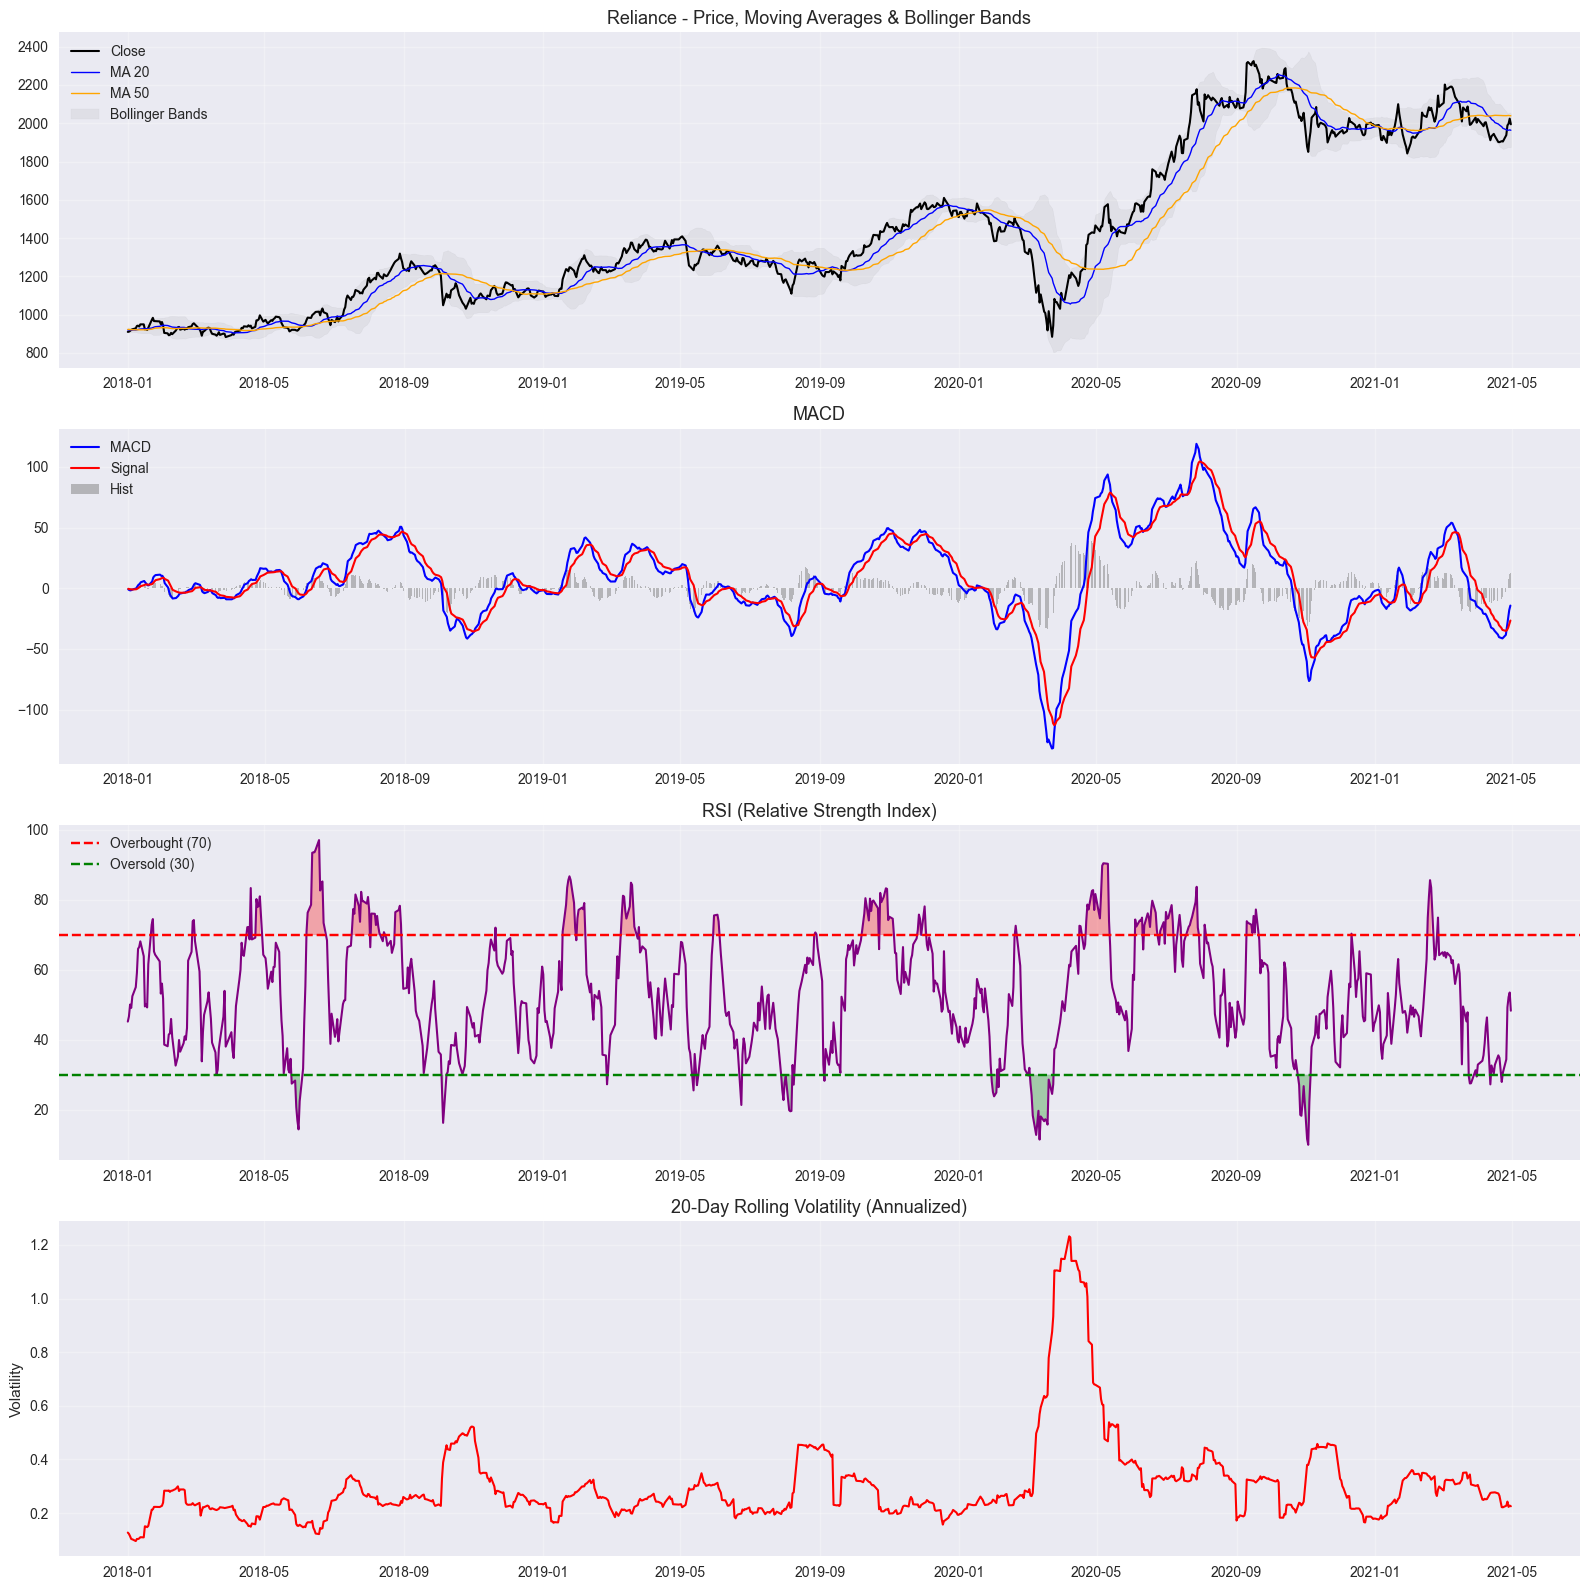

Technical indicators chart saved!


In [5]:
rel = all_featured[all_featured['Symbol'] == 'RELIANCE'].copy()
rel = rel[rel['Date'] >= '2018-01-01']  # Last 3 years for clarity

fig, axes = plt.subplots(4, 1, figsize=(16, 16))

# Price + Moving Averages + Bollinger Bands
axes[0].plot(rel['Date'], rel['Close'],   label='Close',   linewidth=1.5, color='black')
axes[0].plot(rel['Date'], rel['MA_20'],   label='MA 20',   linewidth=1,   color='blue')
axes[0].plot(rel['Date'], rel['MA_50'],   label='MA 50',   linewidth=1,   color='orange')
axes[0].fill_between(rel['Date'], rel['BB_Upper'], rel['BB_Lower'], 
                     alpha=0.1, color='gray', label='Bollinger Bands')
axes[0].set_title('Reliance - Price, Moving Averages & Bollinger Bands', fontsize=13)
axes[0].legend(loc='upper left')
axes[0].grid(True, alpha=0.3)

# MACD
axes[1].plot(rel['Date'], rel['MACD'],        label='MACD',   color='blue',  linewidth=1.5)
axes[1].plot(rel['Date'], rel['MACD_Signal'], label='Signal', color='red',   linewidth=1.5)
axes[1].bar(rel['Date'],  rel['MACD_Hist'],   label='Hist',   color='gray',  alpha=0.5)
axes[1].set_title('MACD', fontsize=13)
axes[1].legend(loc='upper left')
axes[1].grid(True, alpha=0.3)

# RSI
axes[2].plot(rel['Date'], rel['RSI'], color='purple', linewidth=1.5)
axes[2].axhline(70, color='red',   linestyle='--', label='Overbought (70)')
axes[2].axhline(30, color='green', linestyle='--', label='Oversold (30)')
axes[2].fill_between(rel['Date'], rel['RSI'], 70, 
                     where=(rel['RSI'] >= 70), alpha=0.3, color='red')
axes[2].fill_between(rel['Date'], rel['RSI'], 30, 
                     where=(rel['RSI'] <= 30), alpha=0.3, color='green')
axes[2].set_title('RSI (Relative Strength Index)', fontsize=13)
axes[2].legend(loc='upper left')
axes[2].grid(True, alpha=0.3)

# Volatility
axes[3].plot(rel['Date'], rel['Volatility_20'], color='red', linewidth=1.5)
axes[3].set_title('20-Day Rolling Volatility (Annualized)', fontsize=13)
axes[3].set_ylabel('Volatility')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/processed/technical_indicators.png', dpi=150)
plt.show()
print("Technical indicators chart saved!")

In [6]:
# Drop rows with NaN (from rolling windows)
all_featured_clean = all_featured.dropna().reset_index(drop=True)

print(f"Records before cleaning: {len(all_featured)}")
print(f"Records after cleaning:  {len(all_featured_clean)}")
print(f"Records dropped: {len(all_featured) - len(all_featured_clean)}")

# Save to processed folder
all_featured_clean.to_csv('../data/processed/all_stocks_featured.csv', index=False)
print("\n Processed data saved to data/processed/all_stocks_featured.csv")
print(f"Final dataset shape: {all_featured_clean.shape}")

Records before cleaning: 207850
Records after cleaning:  117464
Records dropped: 90386

 Processed data saved to data/processed/all_stocks_featured.csv
Final dataset shape: (117464, 37)
